In [26]:
from pathlib import Path
from typing import Optional, List, Tuple
import gc
import pickle
import sys
import types
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import subprocess

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

In [27]:
BASE_DIR = Path("jr-test") if Path("jr-test").exists() else Path(".")
ARTIFACT_DIR = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

SEQ_LEN = 512
BATCH_SIZE = 32
EPOCHS = 100
VAL_SIZE = 0.10
TEST_SIZE = 0.20
EARLY_STOPPING_PATIENCE = 12
RANDOM_STATE = 42

# MPS can hard-crash the kernel for this transformer training loop on some macOS/PyTorch setups.
# Keep the notebook logic the same, but prefer CUDA and otherwise use CPU for stability.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

KOI_LABEL_MAP_PATH = ARTIFACT_DIR / "koi_label_map.csv"
COMBINED_X_PATH = ARTIFACT_DIR / "combined_X.npy"
COMBINED_Y_PATH = ARTIFACT_DIR / "combined_y.npy"
COMBINED_META_PATH = ARTIFACT_DIR / "combined_metadata.csv"
CLASSES_PATH = ARTIFACT_DIR / "combined_classes.npy"
EXPERIMENT_CONFIGS = [
    {
        "name": "model1",
        "label": "Model 1",
        "d_model": 128,
        "nhead": 8,
        "num_layers": 3,
        "dim_feedforward": 256,
        "dropout": 0.15,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "model_path": ARTIFACT_DIR / "transformer_model1.pt",
        "predictions_path": ARTIFACT_DIR / "val_predictions_transformer_model1.csv",
        "test_predictions_path": ARTIFACT_DIR / "test_predictions_transformer_model1.csv",
    },
    {
        "name": "model2",
        "label": "Model 2",
        "d_model": 192,
        "nhead": 6,
        "num_layers": 2,
        "dim_feedforward": 384,
        "dropout": 0.20,
        "lr": 4e-4,
        "weight_decay": 5e-5,
        "model_path": ARTIFACT_DIR / "transformer_model2.pt",
        "predictions_path": ARTIFACT_DIR / "val_predictions_transformer_model2.csv",
        "test_predictions_path": ARTIFACT_DIR / "test_predictions_transformer_model2.csv",
    },
    {
        "name": "model3",
        "label": "Model 3",
        "d_model": 256,
        "nhead": 8,
        "num_layers": 4,
        "dim_feedforward": 512,
        "dropout": 0.25,
        "lr": 2e-4,
        "weight_decay": 2e-4,
        "model_path": ARTIFACT_DIR / "transformer_model3.pt",
        "predictions_path": ARTIFACT_DIR / "val_predictions_transformer_model3.csv",
        "test_predictions_path": ARTIFACT_DIR / "test_predictions_transformer_model3.csv",
    },
]

Using device: cpu


In [28]:
print(f"Base directory: {BASE_DIR.resolve()}")
print(f"Artifact directory: {ARTIFACT_DIR.resolve()}")
print(f"Device: {DEVICE}")

Base directory: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test
Artifact directory: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts
Device: cpu


In [29]:
PROCESS_SCRIPT = BASE_DIR / "process_dataset_artifact.py"
SUBPROCESS_PYTHON = Path("/Users/jithinrajan/miniconda3/bin/python")
if not SUBPROCESS_PYTHON.exists():
    SUBPROCESS_PYTHON = Path(sys.executable)

In [30]:
def run_processing_subprocess(dataset_name: str) -> None:
    cmd = [str(SUBPROCESS_PYTHON), str(PROCESS_SCRIPT), "--dataset", dataset_name]
    print("Running:", " ".join(cmd))
    result = subprocess.run(
        cmd,
        cwd=str(BASE_DIR.parent if BASE_DIR.name == "jr-test" else BASE_DIR),
        capture_output=True,
        text=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"Processing subprocess failed for {dataset_name} with exit code {result.returncode}")

In [31]:
def ensure_numpy_pickle_compat() -> None:
    aliases = {
        "numpy._core": "numpy.core",
        "numpy._core.numeric": "numpy.core.numeric",
        "numpy._core.multiarray": "numpy.core.multiarray",
        "numpy._core.umath": "numpy.core.umath",
        "numpy._core._multiarray_umath": "numpy.core._multiarray_umath",
    }
    for old_name, new_name in aliases.items():
        if old_name not in sys.modules:
            sys.modules[old_name] = __import__(new_name, fromlist=["*"])

In [32]:
class _LegacyStringArrayCompat:
    def __init__(self) -> None:
        self.data = None

    def __setstate__(self, state) -> None:
        if isinstance(state, tuple) and len(state) == 2:
            self.data = np.asarray(state[1], dtype=object)
        else:
            self.data = np.asarray(state, dtype=object)

    def __len__(self) -> int:
        return len(self.data)

    def __iter__(self):
        return iter(self.data)

    def __array__(self, dtype=None):
        return np.asarray(self.data, dtype=dtype)

    @property
    def dtype(self):
        return object

In [33]:
class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if (module, name) == ("pandas._libs.arrays", "__pyx_unpickle_NDArrayBacked"):
            def custom(cls, checksum, state):
                return _LegacyStringArrayCompat()

            return custom
        return super().find_class(module, name)

In [34]:
def read_pickle_compat(path: Path) -> pd.DataFrame:
    ensure_numpy_pickle_compat()
    try:
        df = pd.read_pickle(path)
    except NotImplementedError as exc:
        if "NDArrayBacked" not in str(exc) and "StringDtype" not in str(exc) and "array([" not in str(exc):
            raise
        with open(path, "rb") as fh:
            df = _CompatUnpickler(fh).load()
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected DataFrame in {path}, got {type(df)}")
    return df

In [35]:
def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    if "KIC" not in df.columns and df.index.name == "KIC":
        df = df.reset_index()
    if "# ID" not in df.columns and df.index.name == "# ID":
        df = df.reset_index()
    return df

In [36]:
def infer_id_column(df: pd.DataFrame) -> str:
    for col in ["KIC", "kepid", "# ID", "id"]:
        if col in df.columns:
            return col
    raise KeyError(f"No ID column found in columns: {list(df.columns)}")

def infer_flux_column(df: pd.DataFrame) -> str:
    for col in ["detflux", "flux", "PDCSAP_FLUX"]:
        if col in df.columns:
            return col
    raise KeyError(f"No flux column found in columns: {list(df.columns)}")

def infer_label_column(df: pd.DataFrame) -> str:
    for col in ["Class", "class", "label", "Label"]:
        if col in df.columns:
            return col
    raise KeyError(f"No label column found in columns: {list(df.columns)}")

In [37]:
def to_float_array(values) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32).reshape(-1)
    return arr[np.isfinite(arr)]


def resample_sequence(values: np.ndarray, fixed_len: int = SEQ_LEN) -> np.ndarray:
    values = to_float_array(values)
    if len(values) == 0:
        return np.zeros(fixed_len, dtype=np.float32)
    if len(values) == 1:
        return np.repeat(values, fixed_len).astype(np.float32)

    x_old = np.linspace(0.0, 1.0, len(values), dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, fixed_len, dtype=np.float32)
    seq = np.interp(x_new, x_old, values).astype(np.float32)

    mean = float(seq.mean())
    std = float(seq.std())
    if std < 1e-6:
        return (seq - mean).astype(np.float32)
    return ((seq - mean) / std).astype(np.float32)

In [38]:
def build_sequence(group: pd.DataFrame, flux_col: str) -> np.ndarray:
    if "quarter" in group.columns:
        group = group.sort_values("quarter")

    parts = []
    for _, row in group.iterrows():
        arr = to_float_array(row[flux_col])
        if len(arr) > 0:
            parts.append(arr)

    if not parts:
        return np.zeros(SEQ_LEN, dtype=np.float32)

    return resample_sequence(np.concatenate(parts), fixed_len=SEQ_LEN)


def remap_label(label: str) -> Optional[str]:
    normalized = str(label).strip().upper()
    mapping = {
        "CONFIRMED": "confirmed",
        "FALSE POSITIVE": "false positives",
        "CANDIDATE": None,
        "NOISE": "false positives",
        "EA": "eclipsing binary",
        "EB": "eclipsing binary",
        "BINARY": "eclipsing binary",
        "GDOR": "variable stars",
        "RRAB": "variable stars",
        "OTHPER": "variable stars",
        "DSCUT": "variable stars",
    }
    return mapping.get(normalized, None)

In [39]:
def read_koi_catalog_labels(csv_path: Path) -> pd.Series:
    catalog = pd.read_csv(csv_path, comment="#")
    catalog["kepid"] = pd.to_numeric(catalog["kepid"], errors="coerce").astype("Int64")
    catalog["koi_disposition"] = catalog["koi_disposition"].astype(str).str.strip().str.upper()
    catalog = catalog.dropna(subset=["kepid", "koi_disposition"])

    priority = ["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]

    def collapse(group: pd.Series) -> Optional[str]:
        values = set(group.tolist())
        for label in priority:
            if label in values:
                return label
        return None

    label_map = catalog.groupby("kepid")["koi_disposition"].apply(collapse).dropna()
    label_map.index = label_map.index.astype(int)
    return label_map


def dataset_artifact_paths(dataset_name: str) -> Tuple[Path, Path]:
    return ARTIFACT_DIR / f"{dataset_name}_X.npy", ARTIFACT_DIR / f"{dataset_name}_meta.csv"

In [40]:
def process_and_save_dataset(pickle_path: Path, dataset_name: str, koi_label_map: Optional[pd.Series] = None) -> Tuple[Path, Path]:
    print(f"Loading {pickle_path.name} ...")
    df = normalize_dataframe(read_pickle_compat(pickle_path))
    id_col = infer_id_column(df)
    flux_col = infer_flux_column(df)
    label_col = infer_label_column(df) if dataset_name == "c00" else None

    keep_cols = [id_col, flux_col]
    if "quarter" in df.columns:
        keep_cols.append("quarter")
    if label_col is not None:
        keep_cols.append(label_col)
    df = df[keep_cols].copy()

    df[id_col] = pd.to_numeric(df[id_col], errors="coerce")
    df = df.dropna(subset=[id_col]).copy()
    df[id_col] = df[id_col].astype(int)

    sequences = []
    records = []

    grouped = df.groupby(id_col, sort=False)
    total_groups = grouped.ngroups
    print(f"Groups to process: {total_groups}")

    for idx, (object_id, group) in enumerate(grouped, start=1):
        if dataset_name == "villanova":
            label = "binary"
        elif dataset_name == "koi":
            if koi_label_map is None or object_id not in koi_label_map.index:
                continue
            label = str(koi_label_map.loc[object_id]).strip().upper()
        elif dataset_name == "c00":
            label = str(group[label_col].iloc[0]).strip()
        else:
            raise ValueError(f"Unsupported dataset name: {dataset_name}")

        label = remap_label(label)

        if label is None or label == "" or label.lower() == "nan":
            continue

        sequences.append(build_sequence(group, flux_col))
        records.append({"dataset": dataset_name, "object_id": object_id, "label": label})

        if idx % 2000 == 0:
            print(f"Processed {idx}/{total_groups} groups")

    if not sequences:
        raise RuntimeError(f"No sequences generated from {pickle_path}")

    X = np.stack(sequences).astype(np.float32)
    meta = pd.DataFrame(records)
    x_path, meta_path = dataset_artifact_paths(dataset_name)
    np.save(x_path, X)
    meta.to_csv(meta_path, index=False)

    print(f"Saved {dataset_name} sequences: {x_path}")
    print(f"Saved {dataset_name} metadata: {meta_path}")
    print(f"Shape: {X.shape}")
    print(meta['label'].value_counts())

    del df, grouped, sequences, records, X, meta
    gc.collect()
    return x_path, meta_path

In [41]:
class IndexedSequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, indices: np.ndarray):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        real_idx = int(self.indices[idx])
        x = np.asarray(self.X[real_idx], dtype=np.float32)
        y = int(self.y[real_idx])
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.long)

In [42]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int, dropout: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        num_classes: int,
        dropout: float,
        max_len: int,
        dim_feedforward: int,
    ):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        pooled = self.norm(encoded.mean(dim=1))
        return self.head(pooled)

In [43]:
def build_loaders_from_indices(
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
):
    train_ds = IndexedSequenceDataset(X, y, train_idx)
    val_ds = IndexedSequenceDataset(X, y, val_idx)
    test_ds = IndexedSequenceDataset(X, y, test_idx)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    )

In [44]:
def evaluate_loss(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> float:
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            total_loss += loss.item()
    return total_loss / max(len(loader), 1)


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    y_train: np.ndarray,
    lr: float,
    weight_decay: float,
) -> dict:
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * np.maximum(class_counts, 1))
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.to(DEVICE)
    train_history = []
    val_history = []
    best_state_dict = None
    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        train_loss = total_loss / max(len(train_loader), 1)
        val_loss = evaluate_loss(model, val_loader, criterion)
        train_history.append(train_loss)
        val_history.append(val_loss)
        print(f"Epoch {epoch + 1:02d}/{EPOCHS} - train_loss={train_loss:.4f} - val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch + 1}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return {
        "train_loss": train_history,
        "val_loss": val_history,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }


def predict(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE))
            y_true.extend(yb.numpy().tolist())
            y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
    return np.asarray(y_true), np.asarray(y_pred)


def instantiate_transformer(config: dict, num_classes: int) -> nn.Module:
    return TransformerClassifier(
        input_size=1,
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        num_classes=num_classes,
        dropout=config["dropout"],
        max_len=SEQ_LEN,
        dim_feedforward=config["dim_feedforward"],
    )


def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    classes: List[str],
    meta: pd.DataFrame,
    eval_idx: np.ndarray,
    predictions_path: Path,
    split_name: str,
) -> dict:
    y_true, y_pred = predict(model, loader)
    id_to_label = {idx: label for idx, label in enumerate(classes)}

    meta_eval = meta.iloc[eval_idx].reset_index(drop=True).copy()
    meta_eval["true_label"] = [id_to_label[idx] for idx in y_true]
    meta_eval["pred_label"] = [id_to_label[idx] for idx in y_pred]
    meta_eval.to_csv(predictions_path, index=False)

    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    target_names = [id_to_label[idx] for idx in range(len(classes))]

    print(f"{split_name} accuracy: {accuracy:.4f}")
    print(f"{split_name} balanced accuracy: {balanced_acc:.4f}")
    print(f"\n{split_name} classification report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(classes)), target_names, rotation=90)
    plt.yticks(range(len(classes)), target_names)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print(f"Saved {split_name.lower()} predictions: {predictions_path}")
    print(meta_eval.head())

    return {
        f"{split_name.lower()}_accuracy": accuracy,
        f"{split_name.lower()}_balanced_accuracy": balanced_acc,
        f"{split_name.lower()}_predictions_path": str(predictions_path),
    }

In [45]:
# Build KOI labels once.

koi_label_map = read_koi_catalog_labels(BASE_DIR / "cumulative_koi.csv")
koi_label_df = koi_label_map.rename("label").reset_index().rename(columns={"kepid": "KIC"})
koi_label_df.to_csv(KOI_LABEL_MAP_PATH, index=False)
print(f"Saved KOI label map: {KOI_LABEL_MAP_PATH}")
print(koi_label_df['label'].value_counts())
koi_label_df.head()

Saved KOI label map: artifacts/koi_label_map.csv
FALSE POSITIVE    4666
CONFIRMED         1973
CANDIDATE         1575
Name: label, dtype: int64


,KIC,label
0,757450,CONFIRMED
1,892772,FALSE POSITIVE
2,1025986,CANDIDATE
3,1026032,FALSE POSITIVE
4,1026957,CONFIRMED


In [46]:
# Process the smaller C_00 dataset in a subprocess so kernel crashes during unpickling do not kill the notebook.

run_processing_subprocess("c00")

Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset c00


python(42853) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/C_00_LC_DATA.pkl ...
Groups to process: 7748
Processed 2000/7748 groups
Processed 4000/7748 groups
Processed 6000/7748 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/c00_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/c00_meta.csv
Final shape: (7748, 256)
label
false positives     4476
variable stars      2980
eclipsing binary     292
Name: count, dtype: int64



In [47]:
# Process the Villanova binaries dataset in a subprocess.
# Run this alone and wait for it to finish before moving on.

run_processing_subprocess("villanova")

Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset villanova


python(42882) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/villanova-kepler-binaries-lcs.pkl ...
Groups to process: 2907
Processed 2000/2907 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/villanova_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/villanova_meta.csv
Final shape: (2907, 256)
label
eclipsing binary    2907
Name: count, dtype: int64



In [48]:
# Process the KOI dataset in a subprocess.
# Run this alone and wait for it to finish before moving on.

run_processing_subprocess("koi")

Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset koi


python(42923) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/koi_cumulative_lcs.pkl ...
Groups to process: 8214
Processed 2000/8214 groups
Processed 4000/8214 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/koi_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/koi_meta.csv
Final shape: (6639, 256)
label
false positives    4666
confirmed          1973
Name: count, dtype: int64



In [49]:
# Combine the already-processed dataset artifacts.

dataset_names = ["c00", "villanova", "koi"]
x_parts = []
meta_parts = []

for dataset_name in dataset_names:
    x_path, meta_path = dataset_artifact_paths(dataset_name)
    if not x_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Missing processed artifact for {dataset_name}: {x_path} / {meta_path}")

    x_part = np.load(x_path, mmap_mode="r")
    meta_part = pd.read_csv(meta_path)
    x_parts.append(np.asarray(x_part, dtype=np.float32))
    meta_parts.append(meta_part)
    print(f"{dataset_name:10s} -> {x_part.shape}")

X = np.concatenate(x_parts, axis=0).astype(np.float32)
meta = pd.concat(meta_parts, ignore_index=True)

FP_LABEL = "false positives"
rng = np.random.default_rng(RANDOM_STATE)
fp_mask = (meta["label"] == FP_LABEL).to_numpy()
fp_indices = np.where(fp_mask)[0]
keep_fp = rng.choice(fp_indices, size=len(fp_indices) // 2, replace=False)
non_fp_indices = np.where(~fp_mask)[0]
keep_indices = np.sort(np.concatenate([non_fp_indices, keep_fp]))
X = X[keep_indices]
meta = meta.iloc[keep_indices].reset_index(drop=True)
print(f"False positives after 50% subsampling: {fp_mask.sum()} -> {(meta['label'] == FP_LABEL).sum()}")

label_counts = meta["label"].value_counts().sort_values(ascending=False)
rare_labels = label_counts[label_counts < 2].index.tolist()
if rare_labels:
    keep_mask = ~meta["label"].isin(rare_labels)
    X = X[keep_mask.to_numpy()]
    meta = meta.loc[keep_mask].reset_index(drop=True)
    print("Dropped classes with fewer than 2 samples:")
    print(rare_labels)

classes = sorted(meta["label"].unique().tolist())
label_to_id = {label: idx for idx, label in enumerate(classes)}
y = meta["label"].map(label_to_id).to_numpy(dtype=np.int64)

np.save(COMBINED_X_PATH, X)
np.save(COMBINED_Y_PATH, y)
np.save(CLASSES_PATH, np.array(classes, dtype=object))
meta.to_csv(COMBINED_META_PATH, index=False)

print(f"Saved combined X: {COMBINED_X_PATH}")
print(f"Saved combined y: {COMBINED_Y_PATH}")
print(f"Saved classes: {CLASSES_PATH}")
print(f"Saved metadata: {COMBINED_META_PATH}")
print(f"Final shape: {X.shape}")
print(meta['label'].value_counts())

del X, y, meta, x_parts, meta_parts
gc.collect()

c00        -> (7748, 256)
villanova  -> (2907, 256)
koi        -> (6639, 256)
False positives after 50% subsampling: 9142 -> 4571
Saved combined X: artifacts/combined_X.npy
Saved combined y: artifacts/combined_y.npy
Saved classes: artifacts/combined_classes.npy
Saved metadata: artifacts/combined_metadata.csv
Final shape: (12723, 256)
false positives     4571
eclipsing binary    3199
variable stars      2980
confirmed           1973
Name: label, dtype: int64


92

In [50]:
# Load the combined arrays once and create train/validation/test splits.

if not COMBINED_X_PATH.exists() or not COMBINED_Y_PATH.exists() or not CLASSES_PATH.exists():
    raise FileNotFoundError("Run the combine block first.")

X = np.load(COMBINED_X_PATH, mmap_mode="r")
y = np.load(COMBINED_Y_PATH, mmap_mode="r")
classes = np.load(CLASSES_PATH, allow_pickle=True).tolist()
meta = pd.read_csv(COMBINED_META_PATH)

indices = np.arange(len(y))
stratify_y = np.asarray(y) if pd.Series(np.asarray(y)).value_counts().min() >= 2 else None
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_y,
)

train_val_y = np.asarray(y)[train_val_idx]
stratify_train_val = train_val_y if pd.Series(train_val_y).value_counts().min() >= 2 else None
val_fraction_of_train_val = VAL_SIZE / (1.0 - TEST_SIZE)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=val_fraction_of_train_val,
    random_state=RANDOM_STATE,
    stratify=stratify_train_val,
)

train_loader, val_loader, test_loader = build_loaders_from_indices(X, y, train_idx, val_idx, test_idx)
results = []
print(f"Train size: {len(train_idx)}")
print(f"Validation size: {len(val_idx)}")
print(f"Test size: {len(test_idx)}")

Train size: 8905
Validation size: 1273
Test size: 2545


In [51]:
# Model 1 - definition

config = EXPERIMENT_CONFIGS[0]
print(config)
model = instantiate_transformer(config, num_classes=len(classes))
model

{'name': 'model1', 'label': 'Model 1', 'd_model': 128, 'nhead': 8, 'num_layers': 3, 'dim_feedforward': 256, 'dropout': 0.15, 'lr': 0.0003, 'weight_decay': 0.0001, 'model_path': PosixPath('artifacts/transformer_model1.pt'), 'predictions_path': PosixPath('artifacts/val_predictions_transformer_model1.csv'), 'test_predictions_path': PosixPath('artifacts/test_predictions_transformer_model1.csv')}


TransformerClassifier(
  (input_projection): Linear(in_features=1, out_features=128, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear

Epoch 01/100 - train_loss=1.0809 - val_loss=0.9074
Epoch 02/100 - train_loss=0.8533 - val_loss=0.7725
Epoch 03/100 - train_loss=0.7976 - val_loss=0.7736
Epoch 04/100 - train_loss=0.7718 - val_loss=0.7237
Epoch 05/100 - train_loss=0.7278 - val_loss=0.7129
Epoch 06/100 - train_loss=0.7096 - val_loss=0.6940
Epoch 07/100 - train_loss=0.6885 - val_loss=0.7654
Epoch 08/100 - train_loss=0.6727 - val_loss=0.6593
Epoch 09/100 - train_loss=0.6531 - val_loss=0.6932
Epoch 10/100 - train_loss=0.6532 - val_loss=0.7203
Epoch 11/100 - train_loss=0.6381 - val_loss=0.6448
Epoch 12/100 - train_loss=0.6236 - val_loss=0.6962
Epoch 13/100 - train_loss=0.6209 - val_loss=0.6430
Epoch 14/100 - train_loss=0.6140 - val_loss=0.6450
Epoch 15/100 - train_loss=0.6062 - val_loss=0.6516
Epoch 16/100 - train_loss=0.5927 - val_loss=0.6479
Epoch 17/100 - train_loss=0.5904 - val_loss=0.6284
Epoch 18/100 - train_loss=0.5801 - val_loss=0.6417
Epoch 19/100 - train_loss=0.5825 - val_loss=0.6389
Epoch 20/100 - train_loss=0.568

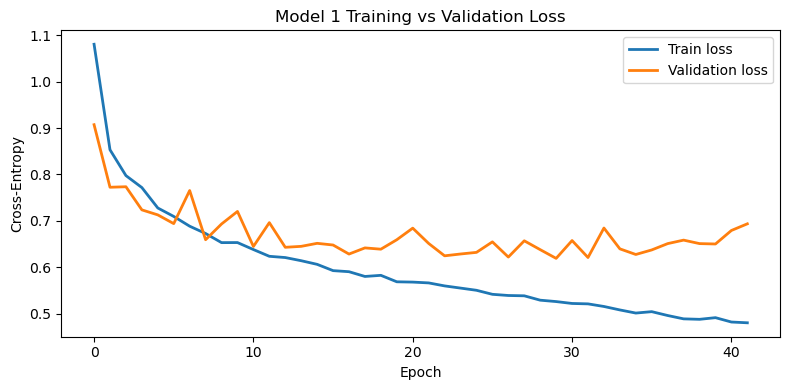

Best epoch: 30
Best validation loss: 0.6191
Saved model: artifacts/transformer_model1.pt


In [52]:
# Model 1 - train

history = train_model(
    model,
    train_loader,
    val_loader,
    np.asarray(y)[train_idx],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "config": config,
}
torch.save(checkpoint, config["model_path"])

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], linewidth=2, label="Train loss")
plt.plot(history["val_loss"], linewidth=2, label="Validation loss")
plt.title(f"{config['label']} Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best epoch: {history['best_epoch']}")
print(f"Best validation loss: {history['best_val_loss']:.4f}")
print(f"Saved model: {config['model_path']}")

Test accuracy: 0.6900
Test balanced accuracy: 0.7369

Test classification report:
                  precision    recall  f1-score   support

       confirmed       0.52      0.95      0.67       395
eclipsing binary       0.87      0.94      0.91       640
 false positives       0.70      0.47      0.56       914
  variable stars       0.68      0.60      0.63       596

        accuracy                           0.69      2545
       macro avg       0.69      0.74      0.69      2545
    weighted avg       0.71      0.69      0.68      2545



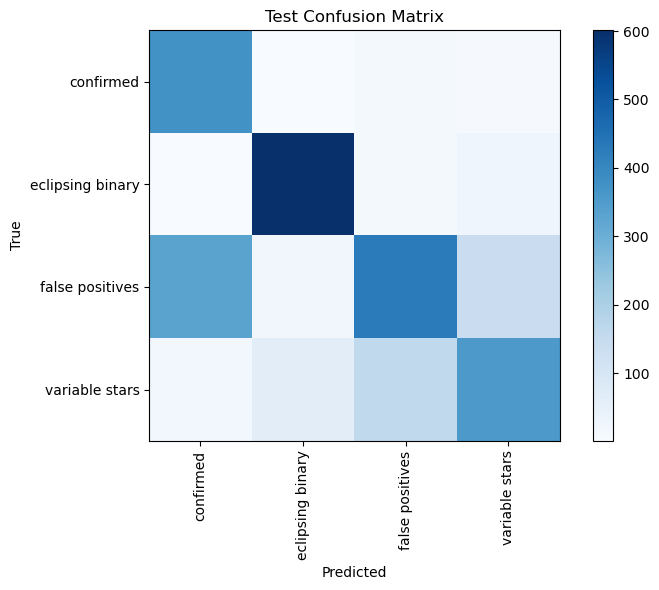

Saved test predictions: artifacts/test_predictions_transformer_model1.csv
     dataset  object_id             label        true_label        pred_label
0        c00  202068470   false positives   false positives   false positives
1        koi    3329985   false positives   false positives         confirmed
2  villanova    2708614  eclipsing binary  eclipsing binary  eclipsing binary
3        c00  202085833   false positives   false positives   false positives
4        c00  202066196    variable stars    variable stars  eclipsing binary


In [53]:
# Model 1 - evaluate on test

checkpoint = torch.load(config["model_path"], map_location=DEVICE)
model = instantiate_transformer(checkpoint["config"], num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

test_result = evaluate_model(
    model,
    test_loader,
    checkpoint["classes"],
    meta,
    np.asarray(checkpoint["test_idx"]),
    checkpoint["config"]["test_predictions_path"],
    split_name="Test",
)
results.append({
    **checkpoint["config"],
    "best_epoch": checkpoint["history"]["best_epoch"],
    "best_val_loss": checkpoint["history"]["best_val_loss"],
    **test_result,
})

In [54]:
# Model 2 - definition

config = EXPERIMENT_CONFIGS[1]
print(config)
model = instantiate_transformer(config, num_classes=len(classes))
model

{'name': 'model2', 'label': 'Model 2', 'd_model': 192, 'nhead': 6, 'num_layers': 2, 'dim_feedforward': 384, 'dropout': 0.2, 'lr': 0.0004, 'weight_decay': 5e-05, 'model_path': PosixPath('artifacts/transformer_model2.pt'), 'predictions_path': PosixPath('artifacts/val_predictions_transformer_model2.csv'), 'test_predictions_path': PosixPath('artifacts/test_predictions_transformer_model2.csv')}


TransformerClassifier(
  (input_projection): Linear(in_features=1, out_features=192, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
        )
        (linear1): Linear(in_features=192, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=384, out_features=192, bias=True)
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_

Epoch 01/100 - train_loss=1.0423 - val_loss=0.8260
Epoch 02/100 - train_loss=0.8168 - val_loss=0.8069
Epoch 03/100 - train_loss=0.7530 - val_loss=0.7083
Epoch 04/100 - train_loss=0.7290 - val_loss=0.7238
Epoch 05/100 - train_loss=0.7079 - val_loss=0.7265
Epoch 06/100 - train_loss=0.6939 - val_loss=0.7154
Epoch 07/100 - train_loss=0.6813 - val_loss=0.6792
Epoch 08/100 - train_loss=0.6758 - val_loss=0.6799
Epoch 09/100 - train_loss=0.6620 - val_loss=0.6739
Epoch 10/100 - train_loss=0.6514 - val_loss=0.6662
Epoch 11/100 - train_loss=0.6399 - val_loss=0.6777
Epoch 12/100 - train_loss=0.6397 - val_loss=0.6687
Epoch 13/100 - train_loss=0.6352 - val_loss=0.6457
Epoch 14/100 - train_loss=0.6259 - val_loss=0.6631
Epoch 15/100 - train_loss=0.6293 - val_loss=0.6738
Epoch 16/100 - train_loss=0.6198 - val_loss=0.6425
Epoch 17/100 - train_loss=0.6120 - val_loss=0.6386
Epoch 18/100 - train_loss=0.6070 - val_loss=0.6441
Epoch 19/100 - train_loss=0.5994 - val_loss=0.6306
Epoch 20/100 - train_loss=0.592

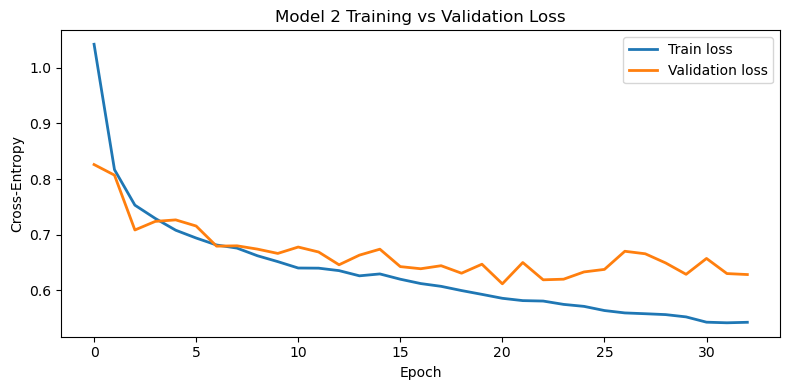

Best epoch: 21
Best validation loss: 0.6115
Saved model: artifacts/transformer_model2.pt


In [55]:
# Model 2 - train

history = train_model(
    model,
    train_loader,
    val_loader,
    np.asarray(y)[train_idx],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "config": config,
}
torch.save(checkpoint, config["model_path"])

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], linewidth=2, label="Train loss")
plt.plot(history["val_loss"], linewidth=2, label="Validation loss")
plt.title(f"{config['label']} Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best epoch: {history['best_epoch']}")
print(f"Best validation loss: {history['best_val_loss']:.4f}")
print(f"Saved model: {config['model_path']}")

Test accuracy: 0.6754
Test balanced accuracy: 0.7336

Test classification report:
                  precision    recall  f1-score   support

       confirmed       0.54      0.93      0.69       395
eclipsing binary       0.87      0.93      0.90       640
 false positives       0.72      0.37      0.49       914
  variable stars       0.59      0.71      0.64       596

        accuracy                           0.68      2545
       macro avg       0.68      0.73      0.68      2545
    weighted avg       0.70      0.68      0.66      2545



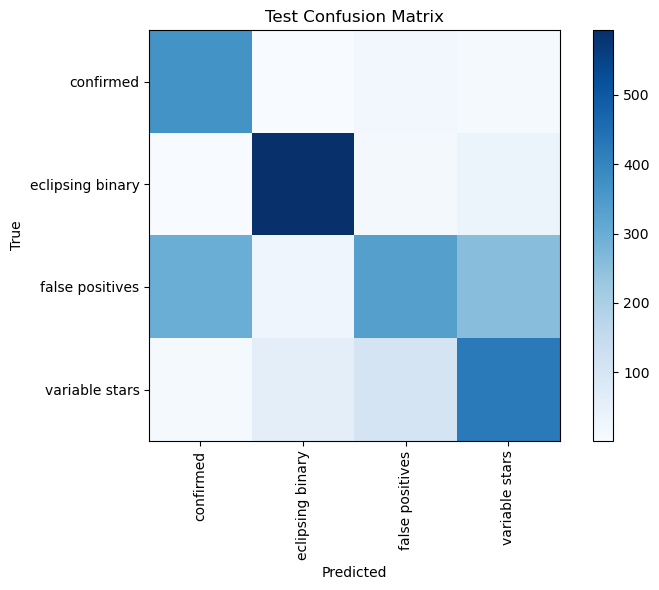

Saved test predictions: artifacts/test_predictions_transformer_model2.csv
     dataset  object_id             label        true_label        pred_label
0        c00  202068470   false positives   false positives   false positives
1        koi    3329985   false positives   false positives         confirmed
2  villanova    2708614  eclipsing binary  eclipsing binary  eclipsing binary
3        c00  202085833   false positives   false positives   false positives
4        c00  202066196    variable stars    variable stars    variable stars


In [56]:
# Model 2 - evaluate on test

checkpoint = torch.load(config["model_path"], map_location=DEVICE)
model = instantiate_transformer(checkpoint["config"], num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

test_result = evaluate_model(
    model,
    test_loader,
    checkpoint["classes"],
    meta,
    np.asarray(checkpoint["test_idx"]),
    checkpoint["config"]["test_predictions_path"],
    split_name="Test",
)
results.append({
    **checkpoint["config"],
    "best_epoch": checkpoint["history"]["best_epoch"],
    "best_val_loss": checkpoint["history"]["best_val_loss"],
    **test_result,
})

In [57]:
# Model 3 - definition

config = EXPERIMENT_CONFIGS[2]
print(config)
model = instantiate_transformer(config, num_classes=len(classes))
model

{'name': 'model3', 'label': 'Model 3', 'd_model': 256, 'nhead': 8, 'num_layers': 4, 'dim_feedforward': 512, 'dropout': 0.25, 'lr': 0.0002, 'weight_decay': 0.0002, 'model_path': PosixPath('artifacts/transformer_model3.pt'), 'predictions_path': PosixPath('artifacts/val_predictions_transformer_model3.csv'), 'test_predictions_path': PosixPath('artifacts/test_predictions_transformer_model3.csv')}


TransformerClassifier(
  (input_projection): Linear(in_features=1, out_features=256, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.25, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.25, inplace=False)
        (dropout2): Dropout(p=0.25, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear

In [ ]:
# Model 3 - train

history = train_model(
    model,
    train_loader,
    val_loader,
    np.asarray(y)[train_idx],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "config": config,
}
torch.save(checkpoint, config["model_path"])

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], linewidth=2, label="Train loss")
plt.plot(history["val_loss"], linewidth=2, label="Validation loss")
plt.title(f"{config['label']} Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best epoch: {history['best_epoch']}")
print(f"Best validation loss: {history['best_val_loss']:.4f}")
print(f"Saved model: {config['model_path']}")

Epoch 01/100 - train_loss=1.0172 - val_loss=0.9136
Epoch 02/100 - train_loss=0.8496 - val_loss=0.8787
Epoch 03/100 - train_loss=0.7823 - val_loss=0.8196
Epoch 04/100 - train_loss=0.7507 - val_loss=0.7679
Epoch 05/100 - train_loss=0.7154 - val_loss=0.7190
Epoch 06/100 - train_loss=0.7015 - val_loss=0.7018
Epoch 07/100 - train_loss=0.6875 - val_loss=0.6957
Epoch 08/100 - train_loss=0.6647 - val_loss=0.7261
Epoch 09/100 - train_loss=0.6646 - val_loss=0.7766
Epoch 10/100 - train_loss=0.6471 - val_loss=0.6985
Epoch 11/100 - train_loss=0.6395 - val_loss=0.6596
Epoch 12/100 - train_loss=0.6345 - val_loss=0.6731
Epoch 13/100 - train_loss=0.6173 - val_loss=0.6955
Epoch 14/100 - train_loss=0.6161 - val_loss=0.6389
Epoch 15/100 - train_loss=0.6126 - val_loss=0.6689
Epoch 16/100 - train_loss=0.5995 - val_loss=0.6493
Epoch 17/100 - train_loss=0.6018 - val_loss=0.6633
Epoch 18/100 - train_loss=0.5873 - val_loss=0.6400
Epoch 19/100 - train_loss=0.5758 - val_loss=0.6511
Epoch 20/100 - train_loss=0.576